# <strong> <center> **Постановка задачи**  </strong>

* **HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.**

А именно:
1. Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
2. Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
3. Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
4. Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?
А также выяснить какие факторы влияют на зарплату специалиста Data Scientist.

# <strong> <center> **Загрузка и обработка данных**  </strong>

In [79]:
# загружаем необходимые библиотеки
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

<strong>  **Загружаем и читаем данные** </strong> 

       

In [80]:
data = pd.read_csv('data/ds_salaries.csv')
data

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...,...
602,602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


<strong> **Проверяем на наличие дубликатов**  </strong>

In [81]:
print('Количество дубликатов: {}'.format(data[data.duplicated()].shape[0]))

Количество дубликатов: 0


<strong> Удаляем признаки, которые неинформативные, либо не нужны для ответа на поставленные вопросы </strong>

In [82]:
data = data.drop(['Unnamed: 0','salary','salary_currency','employee_residence','remote_ratio','experience_level','employment_type','company_location'],axis=1)
data

,work_year,job_title,salary_in_usd,company_size
0,2020,Data Scientist,79833,L
1,2020,Machine Learning Scientist,260000,S
2,2020,Big Data Engineer,109024,M
3,2020,Product Data Analyst,20000,S
4,2020,Machine Learning Engineer,150000,L
...,...,...,...,...
602,2022,Data Engineer,154000,M
603,2022,Data Engineer,126000,M
604,2022,Data Analyst,129000,M
605,2022,Data Analyst,150000,M


<strong> Также, удаляем записи, в которых содержаться данные отличные от **Data scientist** и **Data Engineer** должностях, так как они не участвуют в исследовании  </strong>

In [83]:
indexes_to_drop = data[(data['job_title'] != 'Data Scientist') & (data['job_title'] != 'Data Engineer')].index
data = data.drop(indexes_to_drop,axis=0)

<strong> Переклассифицируем типы данных на категориальные, в соответсвии с заданием </strong>

In [84]:
data['work_year'] = data['work_year'].astype('category')
data['job_title'] = data['job_title'].astype('category')
data['company_size'] = data['company_size'].astype('category')

<strong> Выводим основную статистику признаков </strong>

In [85]:
print(data['company_size'].describe())
print()
print(data['job_title'].describe())
print()
print(data['work_year'].describe())
print()
print(data['salary_in_usd'].describe())

count     275
unique      3
top         M
freq      166
Name: company_size, dtype: object

count                275
unique                 2
top       Data Scientist
freq                 143
Name: job_title, dtype: object

count      275
unique       3
top       2022
freq       166
Name: work_year, dtype: int64

count       275.000000
mean     110365.672727
std       61018.226536
min        2859.000000
25%       65438.000000
50%      104702.000000
75%      150000.000000
max      412000.000000
Name: salary_in_usd, dtype: float64


# <strong> <center> **Разведывательный анализ**  </strong>

<strong> **Визуальный анализ** </strong>

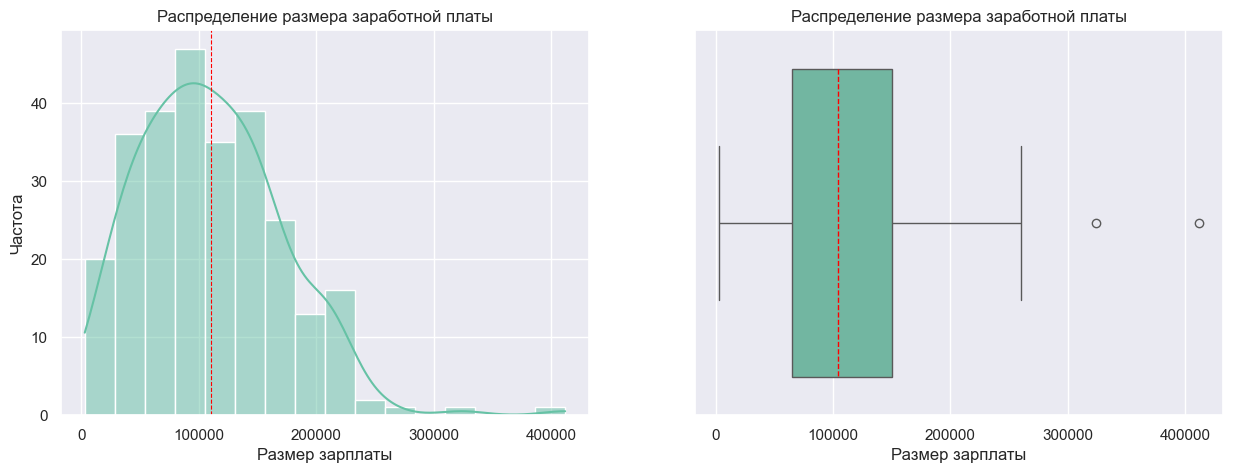

In [86]:
sns.set_theme("notebook") 
sns.set_palette("Set2") 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['salary_in_usd'], kde=True, ax=axes[0])
axes[0].set(xlabel='Размер зарплаты', ylabel='Частота')
axes[0].set_title('Распределение размера заработной платы')
axes[0].axvline(data['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['salary_in_usd'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Размер зарплаты')
axes[1].set_title('Распределение размера заработной платы')

plt.show()

In [87]:
year_data = data['work_year'].value_counts()
fig = px.bar(year_data,
             y=year_data,
             width=500,
             title='Распределение вакансий по годам'
                      
)
fig.show()
year_data

work_year
2022    166
2021     77
2020     32
Name: count, dtype: int64

In [88]:
size_data = data['company_size'].value_counts()
fig = px.bar(size_data,
             y=size_data,
             width=500,
             title='Распределение количества компаний'         
)
fig.show()
size_data

company_size
M    166
L     82
S     27
Name: count, dtype: int64

In [89]:
speciality_data = data[(data['job_title'] == 'Data Scientist') | (data['job_title'] == 'Data Engineer')]
fig = px.histogram(speciality_data,
             x='job_title',
             color='job_title',
             barmode='group',
             width=600,
             height=500, 
             title='Распределение числа должностей'        
)
fig.show()


<strong> Для определения влияния тех или иных признаков на заработную плату составим карту корреляций </strong>

In [90]:
vacancies_dummies = pd.get_dummies(data, columns=['work_year','job_title','company_size']) #Для карты корреляций необходимо преобразовать категориальные признаки в dummy переменные
vacancies_dummies

,salary_in_usd,work_year_2020,work_year_2021,work_year_2022,job_title_Data Engineer,job_title_Data Scientist,company_size_L,company_size_M,company_size_S
0,79833,True,False,False,False,True,True,False,False
7,35735,True,False,False,False,True,True,False,False
10,51321,True,False,False,False,True,False,False,True
11,40481,True,False,False,False,True,True,False,False
12,39916,True,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...
596,210000,False,False,True,False,True,False,True,False
598,160000,False,False,True,False,True,False,True,False
599,130000,False,False,True,False,True,False,True,False
602,154000,False,False,True,True,False,False,True,False


<Axes: >

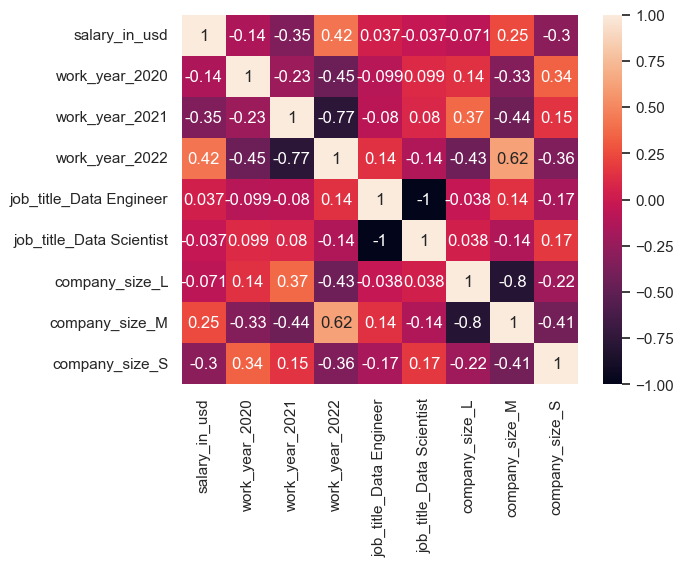

In [91]:
sns.heatmap(vacancies_dummies.corr(numeric_only=True), annot=True) #создаем карту корреляций

Студент на основе визуального анализа дал первичные ответы на поставленный в задании вопрос: «Какие факторы влияют на заработную плату?».!!!!

<strong> **Статистический анализ** </strong>

In [92]:
# Задаем уровень значимости
alpha = 0.05
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


Для удобства построим функции для оценки нормальности и для отвержения или неотвержения нулевой гипотезы

In [93]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))
      

Первый вопрос, на который нам предстоить ответить это **Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?**

Для начала нам нужно понять есть ли различия между годами в заработанной плате

*Нулевая гипотеза* ($H_0$): размер заработной платы за 2020 ($μ_0$), 2021 ($μ_1$), 2022 ($μ_2$) не отличаются друг от друга.

$$ H_0 : μ_0 = μ_1 = μ_2$$

*Альтернативная гипотеза* ($H_0$): размер заработной платы за 2020 ($μ_0$), 2021 ($μ_1$), 2022 ($μ_2$) отличаются.

$$ H_1 : μ_0 \neq μ_1 \neq μ_2 $$

In [94]:
fig = px.box(data_frame=data, 
             y='salary_in_usd',
             x='work_year',
             color='work_year', 
             points='all', 
             labels={'work_year':'Год', 'salary_in_usd':'Зарплата'},
             title='Распределение зарплаты по годам',
             height=800
             )
fig.show()
data_agg = data.groupby('work_year')['salary_in_usd'].describe().round(2)
data_agg

C:\Users\15arh\AppData\Local\Temp\ipykernel_20708\700378010.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,count,mean,std,min,25%,50%,75%,max
work_year,,,,,,,,
2020,32.0,86723.84,70544.14,21669.0,44869.25,69283.5,107000.0,412000.0
2021,77.0,75879.34,48741.67,2859.0,30428.00,75774.0,109000.0,200000.0
2022,166.0,130919.81,55363.40,18442.0,90403.50,131160.0,165355.0,324000.0


Из построенного графика и статистики мы видим что различия есть. Осталось только подтвердить или опровергнуть эти заключения с помощью статистических тестов

Для выбора статистического теста нам необходимо удостовериться в нормальности распределения данных выборок

In [95]:
data_sci = data[data['job_title'] == 'Data Scientist']

salary_2020 = data_sci.loc[data_sci['work_year'] == 2020, 'salary_in_usd']
salary_2021 = data_sci.loc[data_sci['work_year'] == 2021, 'salary_in_usd']
salary_2022 = data_sci.loc[data_sci['work_year'] == 2022, 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для 2020:')
result = stats.shapiro(salary_2020)
decision_normality(result[1])

print('Для 2021:')
result = stats.shapiro(salary_2021)
decision_normality(result[1])

print('Для 2022:')
result = stats.shapiro(salary_2022)
decision_normality(result[1])


Для 2020:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для 2021:
p-value = 0.125
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для 2022:
p-value = 0.327
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным


Исходя из тестов понятно, что распределения не все являются нормальными, а значит, нам придется прибегнуть к непараметрическим тестам

Также, мы знаем, что наши выборки являются независимыми друг от друга, а значит нам подходит тест КРИТЕРИЙ КРАСКЕЛА — УОЛЛИСА

In [96]:
# проводим тест
_, p = stats.kruskal(salary_2020, salary_2021, salary_2022)

# интерпретируем результат
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


Тест показывает, что зарплаты отличаются, поэтому мы можем отвергнуть нулевую гипотезу в пользу альтернативной

Но в задании нам нужно установить, что зарплаты для Data Scientist с каждым годом увеличиваются, для этого нам нужно сначала установить, что зарплата за 2020 год больше, чем за 2021 год и, если это так, подтвердить что зарплата за 2021 год больше, чем за 2022 год

Сначала нам нужно сравнить показатели за 2020 год и 2021 год соотвественно. Из тестов сделанных ранее, мы знаем, что выборка показателей зп за 2020 год не является нормально распределенной, поэтому нам небходим непараметрический тест для подтверждения или опровержения нулевой или альтернативной гипотез.

Но перед проведением тестов сформулируем нулевую и альтернативную гипотезы:  

*Нулевая гипотеза* ($H_0$): размер заработной платы за 2020 год ($μ_0$) меньше или равен зарплате за 2021 год ($μ_1$).

$$ H_0 : μ_0 <= μ_1 $$

*Альтернативная гипотеза* ($H_1$): размер заработной платы за 2020 год ($μ_0$) больше, чем за 2021 год ($μ_1$).

$$ H_1 : μ_0 > μ_1 $$

In [97]:
# проводим тест
_, p = stats.mannwhitneyu(salary_2020, salary_2021, alternative='greater')

# интерпретируем результат
decision_hypothesis(p)

p-value = 0.320
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


Результат теста показал, что у нас нет оснований отвергнуть нулевую гипотезу, которая гласила, что зарплата за 2020 год меньше или равна 2021

Теперь сравним 2021 и 2022 годы. Распределения в этих выборках как мы знаем, являются нормальными, а сами группы независимы,  
поэтому нам подходит параметрический тест **Двувыборочного t-критерия**

Сформулируем нулевую и альтернативную гипотезы:  

*Нулевая гипотеза* ($H_0$): размер заработной платы за 2021 год ($μ_1$) меньше или равен зарплате за 2022 год ($μ_2$).

$$ H_0 : μ_1 <= μ_2 $$

*Альтернативная гипотеза* ($H_1$): размер заработной платы за 2021 год ($μ_1$) больше, чем за 2022 год ($μ_2$).

$$ H_1 : μ_1 > μ_2 $$

Перед использованием этого теста нам нужно установить равенство или неравенство дисперсий в выборках с помощью **теста Левена**

In [98]:
# проводим тест Левена на равенство дисперсий
print('Тест на равенство дисперсий')
result = stats.levene(salary_2021, salary_2022)
p = result[1]
print('p-value = {:.3f}'.format(p))

# интерпретируем результат
if p <= alpha:
    print('Дисперсии не одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=False.')
else:
    print('Дисперсии одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=True.')

Тест на равенство дисперсий
p-value = 0.445
Дисперсии одинаковы, в stats.ttest_ind нужно использовать параметр equal_var=True.


In [99]:
# проводим тест на сравнение средних в группах
_, p = stats.ttest_ind(salary_2021, salary_2022, alternative='greater', equal_var=True)

# интерпретируем результат
decision_hypothesis(p)

p-value = 1.000
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


Статистический тест показал, что размер заработной платы за 2021 год меньше или равен зарплате за 2022 год, что подтверждает нулевую гипотезу

**На основании проведенных тестов, мы можем сделать следующие выводы:  
заработные платы за 3 исследумых года различаются и с каждым годом увеличиваются**

Следующий вопрос, который нам следует разобрать это: **Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?**

Для визуальной оценки построим две коробчатые диаграммы

In [100]:
data_spec = data[data['work_year'] == 2022]

fig = px.box(data_frame=data_spec, 
             y='salary_in_usd',
             x='job_title',
             color='job_title', 
             points='all', 
             labels={'job_title':'Должность', 'salary_in_usd':'Зарплата'},
             title='Распределение зарплаты по должностям')
fig.show()

После визуальной оценки можем предположить, что зарплаты по должностям за 2022 год различаются и специалисты Data Science в среднем получают больше.  
Но нам нужно подтвердить это с помощью статистических тестов.


Для выбора теста нам нужно определить нормальность распределений данных, для этого выполним тест для опредления нормальности Шапиро-Уилка

In [101]:
data_eng_2022 = data_spec[data_spec['job_title'] == 'Data Engineer']['salary_in_usd']

print('Для Data Scientist:')
result = stats.shapiro(salary_2022)
decision_normality(result[1])
print('Для Data Engineer:')
result = stats.shapiro(data_eng_2022)
decision_normality(result[1])

Для Data Scientist:
p-value = 0.327
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для Data Engineer:
p-value = 0.010
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


После проведенного теста видно, что не все данные распределены нормально, а это значит, что будем использовать непраметрический тест Манна-Уитни.  
Выбор этого теста обусловен тем, что мы имеем две независимые группы, где данные распределены не нормально (в одной из них)

Перед проведением теста нам нужно сформулировать нулевую и альтернативную гипотезы:  

*Нулевая гипотеза* ($H_0$): размер заработной платы для Data Scientist ($μ_1$) не отличается от заработной платы для Data Engineer ($μ_2$).

$$ H_0 : μ_1 = μ_2 $$

*Альтернативная гипотеза* ($H_1$) размер заработной платы для Data Scientist ($μ_1$)  отличается от заработной платы для Data Engineer ($μ_2$).

$$ H_1 : μ_1 \neq μ_2 $$

In [102]:
_, p = stats.mannwhitneyu(salary_2022, data_eng_2022)
decision_hypothesis(p)

p-value = 0.155
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


После проведения теста мы можем сделать вывод, что нет статистической важной разницы между зарплатами для разных специальностей в 2022 году и у нас нет оснований отвергать нулевую гипотезу

Следующий вопрос на который нам необходимо ответить: **Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?**

Для визуального анализа данных построим три коробчатые диаграммы показывающие уровень заработных плат для компаний разных размеров

In [103]:
fig = px.box(data_sci,
             x='company_size',
             y='salary_in_usd',
             color='company_size',
             points='all',
             labels={'salary_in_usd': 'Зарплата', 'company_size': 'Размер компании'},
             title='Распределение зарплат по размеру компании',
             height=800)
fig.show()

После визуального анализа можно заметить, чтоуровни заработных плат различаются, но нам необходимо подтвердить или отвергнуть это с помощью статистических анализов.

Перед выбором теста нам нужно понять, нормально ли распределены данные о заработной плате в выборках по разным компаниям, для этого проводим для каждой выборки тесты Шапиро-Уилка. 

In [104]:
data_size_s = data_sci[data_sci['company_size'] == 'S']['salary_in_usd']
data_size_m = data_sci[data_sci['company_size'] == 'M']['salary_in_usd']
data_size_l = data_sci[data_sci['company_size'] == 'L']['salary_in_usd']

print('Для S:')
result = stats.shapiro(data_size_s)
decision_normality(result[1])
print('Для M:')
result = stats.shapiro(data_size_m)
decision_normality(result[1])
print('Для L:')
result = stats.shapiro(data_size_l)
decision_normality(result[1])

Для S:
p-value = 0.189
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для M:
p-value = 0.639
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для L:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


Тесты Шапиро-Уилка показывают, что не все данные распределены нормально.  
Поэтому нам снова нужны непараметрические тесты

Так как мы имеем 3 независимые исследуемые группы, в которых данные распределены ненормально (в одной из них), нам нужно использовать непараметрический тест Краскела-Уоллиса

Перед проведением теста сформулируем нулевую и альтернативную гипотезы:  

*Нулевая гипотеза* ($H_0$): размер заработной платы для Data Scientist в малых компаниях ($μ_0$) не отличается от заработной платы для Data Scientist в средних компаниях ($μ_1$) и от больших компаний ($μ_2$).

$$ H_0 : μ_0 = μ_1 = μ_2 $$

*Альтернативная гипотеза* ($H_1$) размер заработной платы для Data Scientist в малых компаниях ($μ_1$) отличается от заработной платы для Data Scientist в средних ($μ_1$) и больших компаниях ($μ_2$).

$$ H_1 : μ_0 \neq μ_1 \neq μ_2 $$

In [105]:
# проводим тест
_, p = stats.kruskal(data_size_s, data_size_m, data_size_l)

# интерпретируем результат
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


После проведения теста мы видим, что между размерами заработной платы в компаниях разного размера существует статистически важная разница.  
Они различаются, поэтому мы можем отвергнуть нулевую гипотезу в пользу альтернативной

Следующий вопрос, на который нам предстоить ответить, это: **Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?**

Для ответа на этот вопрос будем использовать метод Хи-квадрата, который позволяет установить статистически значимые закономерности в данных.

Для начала создадим таблицу сопряженности. Она позволяет анализировать взаимосвязь между переменными, подсчитывая частоту их совместного появления. И необходима для проведения теста Хи-квадрат.

In [106]:

position_size_table = pd.crosstab(
    data['company_size'],
    data['job_title'],
    margins=True,
    margins_name="Всего"
)


Перед проведением теста сформулируем нулевую и альтернативную гипотезы:  

*Нулевая гипотеза* ($H_0$): Нет связи между наличием должности Data Scientist и размером компании


*Альтернативная гипотеза* ($H_1$) Распределение наличия/отсутствия должности одинаково для компаний разных размеров



In [107]:
from scipy.stats import chi2_contingency

engi_size_table = position_size_table['Data Engineer']
sci_size_table = position_size_table['Data Scientist']

_, p, _, _ = chi2_contingency(engi_size_table)

# интерпретируем результат
print('Для Data Engineer')
decision_hypothesis(p)


_, p, _, _ = chi2_contingency(sci_size_table)

# интерпретируем результат
print('Для Data Scientist')
decision_hypothesis(p)


Для Data Engineer
p-value = 1.000
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.
Для Data Scientist
p-value = 1.000
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


В обоих случаях (для Data Engineer и Data Scientist) тестом статистически подтверждена нулевая гипотеза об отсутствии связи между специальностями и размером компании

# <strong> <center> *Дополнительные исследования*  </strong>

Читаем данные

In [108]:
data_2 = pd.read_csv('data/ds_salaries.csv')
data_2

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
...,...,...,...,...,...,...,...,...,...,...,...,...
602,602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M
603,603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M
604,604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M
605,605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M


Удаление столбцов, которые не будут исследоваться

In [109]:
data_2 = data_2.drop(['Unnamed: 0','salary','salary_currency','employee_residence','company_location','employment_type','company_size'],axis=1)
data_2

,work_year,experience_level,job_title,salary_in_usd,remote_ratio
0,2020,MI,Data Scientist,79833,0
1,2020,SE,Machine Learning Scientist,260000,0
2,2020,SE,Big Data Engineer,109024,50
3,2020,MI,Product Data Analyst,20000,0
4,2020,SE,Machine Learning Engineer,150000,50
...,...,...,...,...,...
602,2022,SE,Data Engineer,154000,100
603,2022,SE,Data Engineer,126000,100
604,2022,SE,Data Analyst,129000,0
605,2022,SE,Data Analyst,150000,100


Переформатирование столбцов в категориальный признак 

In [110]:
data_2['work_year'] = data_2['work_year'].astype('category')
data_2['remote_ratio'] = data_2['remote_ratio'].astype('category')
data_2['job_title'] = data_2['job_title'].astype('category')
data_2['experience_level'] = data_2['experience_level'].astype('category')
data_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   work_year         607 non-null    category
 1   experience_level  607 non-null    category
 2   job_title         607 non-null    category
 3   salary_in_usd     607 non-null    int64   
 4   remote_ratio      607 non-null    category
dtypes: category(4), int64(1)
memory usage: 10.1 KB


Удаление записей не относящиеся к специальностям Data Scientist или Data Engineer

In [111]:
indexes_to_drop = data_2[(data_2['job_title'] != 'Data Scientist') & (data_2['job_title'] != 'Data Engineer')].index
data_2 = data_2.drop(indexes_to_drop,axis=0)
data_2

,work_year,experience_level,job_title,salary_in_usd,remote_ratio
0,2020,MI,Data Scientist,79833,0
7,2020,MI,Data Scientist,35735,50
10,2020,EN,Data Scientist,51321,0
11,2020,MI,Data Scientist,40481,0
12,2020,EN,Data Scientist,39916,0
...,...,...,...,...,...
596,2022,SE,Data Scientist,210000,100
598,2022,MI,Data Scientist,160000,100
599,2022,MI,Data Scientist,130000,100
602,2022,SE,Data Engineer,154000,100


Визуализация признака уровня заработной платы по отношению к уровню опыта

In [112]:
data_2['experience_level'] = data_2['experience_level'].apply(lambda x: 'Junior' if x == 'EN' else 'Intermediate' if x == 'MI' else 'Senior' if x == 'SE' else 'Expert')
fig = px.box(data_2,
             x='experience_level',
             y='salary_in_usd',
             color='experience_level',
             labels={'experience_level': 'Необходимый опыт', 'salary_in_usd': 'Заработная плата'},
             title='Распределение заработной платы по отношению к уровню опыта')
fig.show()

Видим отличия в уровнях заработной платы необходимо подтвердить статистическими тестами

Для начала проверяем нормальность распределения с помощью теста Шапиро-Уилка

In [113]:
data_sal_junior = data_2[data_2['experience_level'] == 'Junior']['salary_in_usd']
data_sal_inter = data_2[data_2['experience_level'] == 'Intermediate']['salary_in_usd']
data_sal_senior = data_2[data_2['experience_level'] == 'Senior']['salary_in_usd']
data_sal_expert = data_2[data_2['experience_level'] == 'Expert']['salary_in_usd']

print('Для Junior:')
result = stats.shapiro(data_sal_junior)
decision_normality(result[1])

print('Для Intermediate:')
result = stats.shapiro(data_sal_inter)
decision_normality(result[1])

print('Для Senior:')
result = stats.shapiro(data_sal_senior)
decision_normality(result[1])

print('Для Expert:')
result = stats.shapiro(data_sal_expert)
decision_normality(result[1])

Для Junior:
p-value = 0.557
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для Intermediate:
p-value = 0.020
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для Senior:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для Expert:
p-value = 0.337
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным


Распределения не все нормальные (два из четырёх), используем непраметрический тест Краскела-Уоллиса

Перед проведением теста сформулируем нулевую и альтернативную гипотезы:  

*Нулевая гипотеза* ($H_0$): размер заработной платы для Data Scientist и Data Engineer с опытом Junior ($μ_0$), Intermediate ($μ_1$), Senior ($μ_2$) и Expert ($μ_3$) не имеют различий.

$$ H_0 : μ_0 = μ_1 = μ_2 = μ_3 $$

*Альтернативная гипотеза* ($H_1$) размеры заработной платы имеют различия.

$$ H_1 : μ_0 \neq μ_1 \neq μ_2 \neq μ_3 $$

In [114]:
# проводим тест
_, p = stats.kruskal(data_sal_junior, data_sal_inter, data_sal_senior, data_sal_expert)

# интерпретируем результат
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


Тест показывает, что различия есть и мы можем отвергнуть нулевую гипотезу в пользу альтернативной

Таким образом можем заявить, что уровень опыта играет роль в размере заработной платы

Визуализация признака заработной платы в зависимости от обьема удаленной работы

In [117]:
data_2['remote_ratio'] = data_2['remote_ratio'].apply(lambda x: 'Нет удалёнки' if x == 0 else 'Частичная удалёнка' if x == 50 else 'Полностью удаленная работа')
fig = px.box(data_2,
             x='remote_ratio',
             y='salary_in_usd',
             color='remote_ratio',
             labels={'remote_ratio': 'Количество удалёнки', 'salary_in_usd': 'Заработная плата'},
             title='Распределение заработной платы по отношению к количеству удаленной работы'
             )
fig.show()

На визуализации можем заметить различия, необходимо провести статистические тесты для подтверждения.

Проверяем нормальность распределения данных с помощью теста Шапиро-Уилка

In [121]:
data_no_dist = data_2[data_2['remote_ratio'] == 'Нет удалёнки']['salary_in_usd']
data_half_dist = data_2[data_2['remote_ratio'] == 'Частичная удалёнка']['salary_in_usd']
data_full_dist = data_2[data_2['remote_ratio'] == 'Полностью удаленная работа']['salary_in_usd']

print('Для Безудалённой работы:')
result = stats.shapiro(data_no_dist)
decision_normality(result[1])

print('Для Полу-удалённой работы:')
result = stats.shapiro(data_half_dist)
decision_normality(result[1])

print('Для Поолеостью удалённой работы:')
result = stats.shapiro(data_full_dist)
decision_normality(result[1])

Для Безудалённой работы:
p-value = 0.191
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для Полу-удалённой работы:
p-value = 0.477
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным
Для Поолеостью удалённой работы:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


Не все данные являются нормально распределенными (одна выборка из трёх)

Для теста неправильно распределенных трёх независимых выборок выбираем тест Краскела-Уоллиса

Сформулируем нулевую и альтернативную гипотезы:

*Нулевая гипотеза* ($H_0$): размер заработной платы для Data Scientist и Data Engineer с нулевым объёмом удалённой работы ($μ_0$), полу-удалённой работой ($μ_1$), и полностью удалённой работой ($μ_2$) не имеют различий.

$$ H_0 : μ_0 = μ_1 = μ_2 $$

*Альтернативная гипотеза* ($H_1$) размеры заработной платы имеют различия.

$$ H_1 : μ_0 \neq μ_1 \neq μ_2  $$

In [122]:
# проводим тест
_, p = stats.kruskal(data_no_dist, data_half_dist, data_full_dist)

# интерпретируем результат
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


Тест показал наличие статистически значимой разницы, поэтому можем отвергнуть нулевую гипотезу в пользу альтернативной и утверждать, что уровень удаленной работы влияет на заработную плату

# <strong> <center> *Итоговые выводы*  </strong>

Подводя итоги проделанной работы, а именно: визуального анализа, разведывательного анализа, проведения статистических тестов можно утверждать что:   
1. Наблюдается ежегодный рост Заработной платы специалистов Data Scientist.
2. в 2022 году зарплаты Data Scintist и Data Engineer не различаются (нет статистически значимой разницы)
3. Зарплаты специалистов Data Science в компаниях разных размеров отличаются (имеется статистически значимая разница)
4. Связи между размером компаний и наличии должностей Data Scientist и Data Engineer нет (нет статистически значимой разницы)  
А также мы можем утверждать, что:
5. Уровень опыта влияет на размер заработной платы (есть статистически значимая разница)
6. Объём удалённой работы также влияет на заработную плату (есть статистически важная разница)